# Research: Turn of the Month Effect (Issue #21)

## Contexte
- **Performance actuelle**: Sharpe 0.127, CAGR 4.8%, MaxDD 23.7%
- **Problemes**: Approximation imprecise des jours de trading, leverage 1.5x amplifie pertes
- **Objectif**: Sharpe > 0.3 en optimisant la fenetre et le sizing

## Hypotheses a tester
1. L'effet ToM existe-t-il vraiment? Stats par jour du mois
2. Quelle fenetre optimale? J-1/J+1 a J-5/J+5
3. SPY seul vs SPY+QQQ vs multi-ETF
4. Impact du leverage (1.0x vs 1.5x vs 2.0x)
5. SMA200 filter: utile ou pas?
6. Combinaison avec d'autres effets calendaires

## References
- Ariel (1987) "A Monthly Effect in Stock Returns"
- Lakonishok & Smidt (1988) "Are Seasonal Anomalies Real?"

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Telecharger SPY et QQQ
tickers = ['SPY', 'QQQ']
start = '2000-01-01'
end = '2026-01-01'

data = yf.download(tickers, start=start, end=end)
spy = data['Close']['SPY'].dropna()
qqq = data['Close']['QQQ'].dropna()

# Calculer le jour de trading dans le mois et jours restants
spy_df = pd.DataFrame({'close': spy})
spy_df['return'] = spy_df['close'].pct_change()
spy_df['month'] = spy_df.index.month
spy_df['year'] = spy_df.index.year
spy_df['ym'] = spy_df['year'] * 100 + spy_df['month']

# Trading day of month and trading days remaining
spy_df['td_of_month'] = spy_df.groupby('ym').cumcount() + 1
spy_df['td_total'] = spy_df.groupby('ym')['close'].transform('count')
spy_df['td_remaining'] = spy_df['td_total'] - spy_df['td_of_month']

print(f"Periode: {spy_df.index[0].date()} a {spy_df.index[-1].date()}")
print(f"Jours de trading: {len(spy_df)}")
print(f"Mois complets: {spy_df['ym'].nunique()}")

[*********************100%***********************]  2 of 2 completed

Periode: 2000-01-03 a 2025-12-31
Jours de trading: 6539
Mois complets: 312


## Hypothese 1: L'effet Turn-of-Month existe-t-il?

Regardons les rendements moyens par jour de trading du mois.

Rendement moyen par jour de trading du mois (SPY 2000-2025):
Day       Mean     Ann.      Std   t-stat     N
---------------------------------------------
1       0.178%    44.7%   1.318%    2.38   311 ***
2       0.058%    14.6%   1.156%    0.89   312
3       0.025%     6.3%   1.157%    0.38   312
4       0.025%     6.3%   1.344%    0.33   312
5       0.020%     5.0%   1.069%    0.33   312
6      -0.006%    -1.4%   1.239%   -0.08   312
7       0.014%     3.6%   1.353%    0.19   312
8      -0.044%   -11.0%   1.199%   -0.64   312
9       0.089%    22.5%   1.546%    1.02   312
10      0.055%    13.9%   1.172%    0.83   312
11      0.154%    38.7%   1.355%    2.00   312 ***
12      0.131%    33.1%   1.207%    1.92   312 **
13     -0.095%   -23.8%   1.146%   -1.46   312
14     -0.181%   -45.6%   1.176%   -2.72   312 ***
15      0.046%    11.5%   1.136%    0.71   312
16      0.044%    11.0%   1.242%    0.62   311
17      0.035%     8.8%   1.146%    0.54   311
18      0.073%    18.3%   1.066

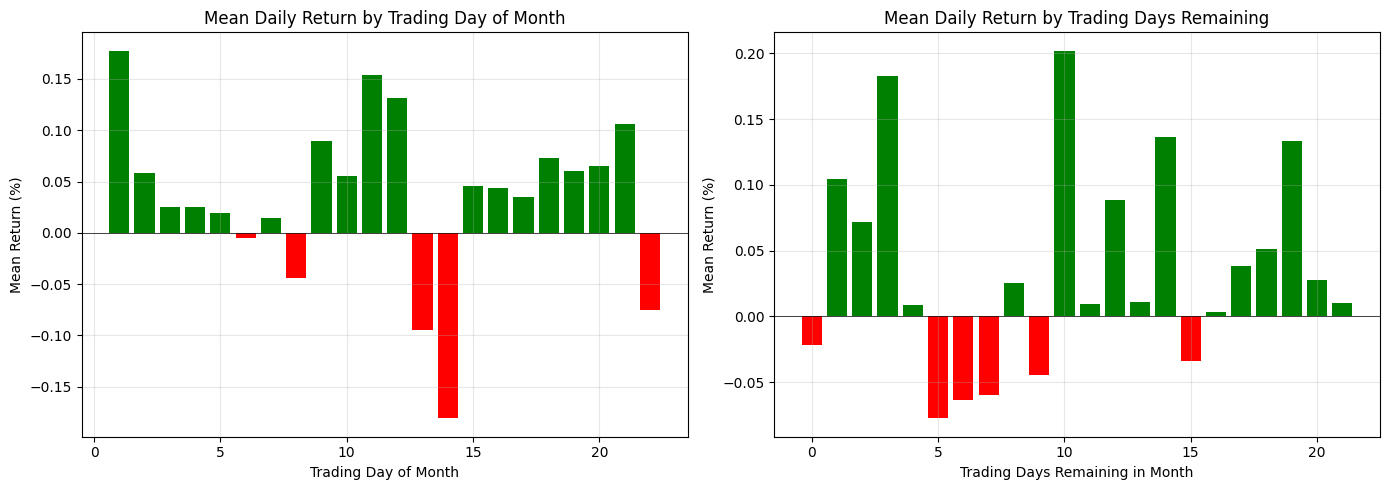

In [2]:
# Rendement moyen par jour de trading du mois
by_td = spy_df.groupby('td_of_month')['return'].agg(['mean', 'std', 'count'])
by_td = by_td[by_td['count'] > 50]  # Garder seulement jours avec assez de data
by_td['annualized'] = by_td['mean'] * 252
by_td['t_stat'] = by_td['mean'] / (by_td['std'] / np.sqrt(by_td['count']))

print("Rendement moyen par jour de trading du mois (SPY 2000-2025):")
print(f"{'Day':<5} {'Mean':>8} {'Ann.':>8} {'Std':>8} {'t-stat':>8} {'N':>5}")
print("-" * 45)
for td, row in by_td.iterrows():
    marker = ' ***' if abs(row['t_stat']) > 2 else (' **' if abs(row['t_stat']) > 1.5 else '')
    print(f"{td:<5} {row['mean']*100:>7.3f}% {row['annualized']*100:>7.1f}% {row['std']*100:>7.3f}% {row['t_stat']:>7.2f} {int(row['count']):>5}{marker}")

# Rendement par jours restants
by_remaining = spy_df.groupby('td_remaining')['return'].agg(['mean', 'count'])
by_remaining = by_remaining[by_remaining['count'] > 50]

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(by_td.index, by_td['mean'] * 100, color=['green' if x > 0 else 'red' for x in by_td['mean']])
axes[0].set_title('Mean Daily Return by Trading Day of Month')
axes[0].set_xlabel('Trading Day of Month')
axes[0].set_ylabel('Mean Return (%)')
axes[0].axhline(y=0, color='black', linewidth=0.5)
axes[0].grid(True, alpha=0.3)

axes[1].bar(by_remaining.index, by_remaining['mean'] * 100, color=['green' if x > 0 else 'red' for x in by_remaining['mean']])
axes[1].set_title('Mean Daily Return by Trading Days Remaining')
axes[1].set_xlabel('Trading Days Remaining in Month')
axes[1].set_ylabel('Mean Return (%)')
axes[1].axhline(y=0, color='black', linewidth=0.5)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Hypothese 2: Fenetre optimale

Testons differentes fenetres ToM et mesurons le Sharpe de chacune.

In [3]:
def tom_backtest(spy_df, days_before, days_after, leverage=1.0):
    """Backtest Turn-of-Month: buy last N + first N trading days."""
    # In window: td_remaining < days_before OR td_of_month <= days_after
    in_window = (spy_df['td_remaining'] < days_before) | (spy_df['td_of_month'] <= days_after)
    
    returns = spy_df['return'].copy()
    strategy_ret = returns * in_window.astype(float) * leverage
    strategy_ret = strategy_ret.dropna()
    
    cum = (1 + strategy_ret).cumprod()
    total = cum.iloc[-1] - 1
    years = len(strategy_ret) / 252
    cagr = (1 + total) ** (1/years) - 1
    vol = strategy_ret.std() * np.sqrt(252)
    sharpe = (cagr - 0.04) / vol if vol > 0 else 0
    max_dd = ((cum / cum.cummax()) - 1).min()
    pct_invested = in_window.mean()
    
    return {
        'sharpe': sharpe, 'cagr': cagr, 'max_dd': max_dd, 'vol': vol,
        'total_ret': total, 'pct_invested': pct_invested, 'cum': cum
    }

# Grid search fenetres
print(f"{'Before':<8} {'After':<7} {'Sharpe':>7} {'CAGR':>7} {'MaxDD':>7} {'Vol':>7} {'Invested':>9}")
print("-" * 55)

best = {'sharpe': -999}
results = {}

for before in [1, 2, 3, 4, 5]:
    for after in [1, 2, 3, 4, 5]:
        r = tom_backtest(spy_df, before, after, leverage=1.0)
        key = f"{before}/{after}"
        results[key] = r
        print(f"{before:<8} {after:<7} {r['sharpe']:>7.3f} {r['cagr']:>6.1%} {r['max_dd']:>6.1%} {r['vol']:>6.1%} {r['pct_invested']:>8.0%}")
        if r['sharpe'] > best['sharpe']:
            best = r
            best['config'] = (before, after)

print(f"\nMeilleure config: {best['config'][0]}d before / {best['config'][1]}d after, Sharpe={best['sharpe']:.3f}")

Before   After    Sharpe    CAGR   MaxDD     Vol  Invested
-------------------------------------------------------
1        1        -0.398   1.7% -14.5%   5.7%      10%
1        2        -0.236   2.3% -14.9%   7.0%      14%
1        3        -0.177   2.6% -18.4%   8.1%      19%
1        4        -0.133   2.8% -28.3%   9.3%      24%
1        5        -0.106   2.9% -31.3%  10.0%      29%
2        1        -0.153   2.9% -18.3%   7.1%      14%
2        2        -0.055   3.5% -16.5%   8.2%      19%
2        3        -0.025   3.8% -20.7%   9.1%      24%
2        4        -0.003   4.0% -33.4%  10.2%      29%
2        5         0.014   4.1% -34.4%  10.9%      33%
3        1        -0.033   3.7% -18.4%   8.1%      19%
3        2         0.041   4.4% -17.8%   9.0%      24%
3        3         0.061   4.6% -19.0%   9.9%      29%
3        4         0.073   4.8% -33.4%  10.9%      33%
3        5         0.085   5.0% -33.1%  11.5%      38%
4        1         0.207   5.9% -13.5%   9.3%      24%
4    

## Hypothese 3: SPY vs SPY+QQQ vs multi-ETF

Testons si ajouter QQQ ou d'autres ETFs ameliore la strategie.

In [4]:
# Telecharger plus de tickers
extra_tickers = ['SPY', 'QQQ', 'IWM', 'DIA']
extra_data = yf.download(extra_tickers, start=start, end=end)
extra_closes = extra_data['Close'].dropna()

# Utiliser la meilleure fenetre trouvee
bb, ba = best['config']
print(f"Fenetre optimale: {bb}d before / {ba}d after")
print()

# ToM pour chaque ticker individuellement
print(f"{'Ticker':<6} {'Sharpe':>7} {'CAGR':>7} {'MaxDD':>7}")
print("-" * 35)

for ticker in extra_tickers:
    t_df = pd.DataFrame({'close': extra_closes[ticker]})
    t_df['return'] = t_df['close'].pct_change()
    t_df['month'] = t_df.index.month
    t_df['year'] = t_df.index.year
    t_df['ym'] = t_df['year'] * 100 + t_df['month']
    t_df['td_of_month'] = t_df.groupby('ym').cumcount() + 1
    t_df['td_total'] = t_df.groupby('ym')['close'].transform('count')
    t_df['td_remaining'] = t_df['td_total'] - t_df['td_of_month']
    
    r = tom_backtest(t_df, bb, ba, leverage=1.0)
    print(f"{ticker:<6} {r['sharpe']:>7.3f} {r['cagr']:>6.1%} {r['max_dd']:>6.1%}")

# Portfolio: equal weight SPY+QQQ
spy_qqq_df = pd.DataFrame({
    'close': (extra_closes['SPY'] / extra_closes['SPY'].iloc[0] + extra_closes['QQQ'] / extra_closes['QQQ'].iloc[0]) / 2
})
spy_qqq_df['return'] = spy_qqq_df['close'].pct_change()
spy_qqq_df['month'] = spy_qqq_df.index.month
spy_qqq_df['year'] = spy_qqq_df.index.year
spy_qqq_df['ym'] = spy_qqq_df['year'] * 100 + spy_qqq_df['month']
spy_qqq_df['td_of_month'] = spy_qqq_df.groupby('ym').cumcount() + 1
spy_qqq_df['td_total'] = spy_qqq_df.groupby('ym')['close'].transform('count')
spy_qqq_df['td_remaining'] = spy_qqq_df['td_total'] - spy_qqq_df['td_of_month']

r = tom_backtest(spy_qqq_df, bb, ba, leverage=1.0)
print(f"{'SPY+QQQ':<6} {r['sharpe']:>7.3f} {r['cagr']:>6.1%} {r['max_dd']:>6.1%}")

[                       0%                       ]

[**********************50%                       ]  2 of 4 completed

[**********************75%***********            ]  3 of 4 completed

[*********************100%***********************]  4 of 4 completed

Fenetre optimale: 4d before / 3d after

Ticker  Sharpe    CAGR   MaxDD
-----------------------------------
SPY      0.286   7.1% -18.2%
QQQ      0.165   6.5% -51.1%
IWM      0.253   7.5% -22.4%
DIA      0.258   6.6% -17.0%
SPY+QQQ   0.247   7.0% -29.9%


## Hypothese 4: Impact du leverage

La strategie est investie ~40% du temps. Le leverage peut compenser
le faible temps d'exposition, mais amplifie aussi les drawdowns.

In [5]:
bb, ba = best['config']

print(f"Fenetre: {bb}d before / {ba}d after")
print(f"{'Leverage':>10} {'Sharpe':>7} {'CAGR':>7} {'MaxDD':>7} {'Vol':>7}")
print("-" * 45)

for lev in [1.0, 1.25, 1.5, 1.75, 2.0]:
    r = tom_backtest(spy_df, bb, ba, leverage=lev)
    print(f"{lev:>10.2f} {r['sharpe']:>7.3f} {r['cagr']:>6.1%} {r['max_dd']:>6.1%} {r['vol']:>6.1%}")

Fenetre: 4d before / 3d after
  Leverage  Sharpe    CAGR   MaxDD     Vol
---------------------------------------------
      1.00   0.258   6.8% -18.2%  10.9%
      1.25   0.322   8.4% -22.5%  13.6%
      1.50   0.361   9.9% -26.6%  16.3%
      1.75   0.386  11.4% -30.5%  19.1%
      2.00   0.401  12.7% -34.3%  21.8%


## Hypothese 5: SMA200 filter

L'actuel utilise un SMA200 filter. Testons son impact.

Fenetre: 4d before / 3d after

--- Leverage 1.0x ---
  No filter:  Sharpe=0.258, CAGR=6.8%, MaxDD=-18.2%, Invested=33%
  SMA200:     Sharpe=0.350, CAGR=6.3%, MaxDD=-10.3%, Invested=24%

--- Leverage 1.5x ---
  No filter:  Sharpe=0.361, CAGR=9.9%, MaxDD=-26.6%, Invested=33%
  SMA200:     Sharpe=0.547, CAGR=9.5%, MaxDD=-15.3%, Invested=24%



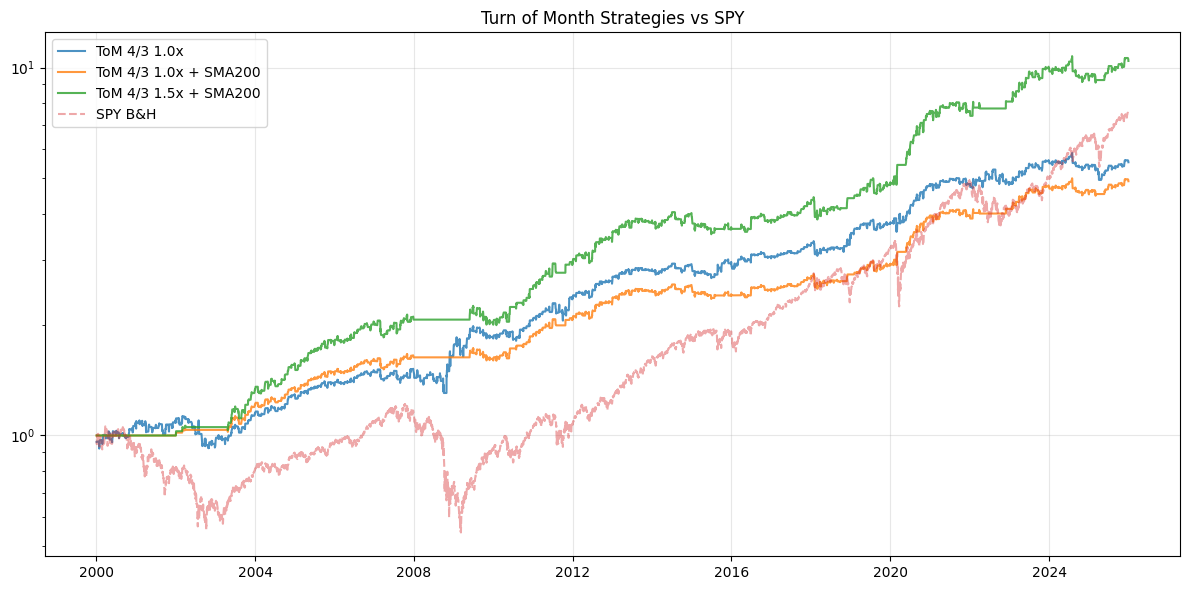

In [6]:
# SMA filter
spy_df['sma200'] = spy_df['close'].rolling(200).mean()
spy_df['above_sma'] = spy_df['close'] > spy_df['sma200']

def tom_backtest_filtered(spy_df, days_before, days_after, leverage=1.0, use_sma=False):
    in_window = (spy_df['td_remaining'] < days_before) | (spy_df['td_of_month'] <= days_after)
    if use_sma:
        in_window = in_window & spy_df['above_sma']
    
    returns = spy_df['return'].copy()
    strategy_ret = returns * in_window.astype(float) * leverage
    strategy_ret = strategy_ret.dropna()
    
    cum = (1 + strategy_ret).cumprod()
    total = cum.iloc[-1] - 1
    years = len(strategy_ret) / 252
    cagr = (1 + total) ** (1/years) - 1
    vol = strategy_ret.std() * np.sqrt(252)
    sharpe = (cagr - 0.04) / vol if vol > 0 else 0
    max_dd = ((cum / cum.cummax()) - 1).min()
    pct_invested = in_window.mean()
    
    return {
        'sharpe': sharpe, 'cagr': cagr, 'max_dd': max_dd, 'vol': vol,
        'pct_invested': pct_invested, 'cum': cum
    }

bb, ba = best['config']
print(f"Fenetre: {bb}d before / {ba}d after")
print()

for lev in [1.0, 1.5]:
    print(f"--- Leverage {lev}x ---")
    r_no = tom_backtest_filtered(spy_df, bb, ba, lev, use_sma=False)
    r_sma = tom_backtest_filtered(spy_df, bb, ba, lev, use_sma=True)
    print(f"  No filter:  Sharpe={r_no['sharpe']:.3f}, CAGR={r_no['cagr']:.1%}, MaxDD={r_no['max_dd']:.1%}, Invested={r_no['pct_invested']:.0%}")
    print(f"  SMA200:     Sharpe={r_sma['sharpe']:.3f}, CAGR={r_sma['cagr']:.1%}, MaxDD={r_sma['max_dd']:.1%}, Invested={r_sma['pct_invested']:.0%}")
    print()

# Graphique comparatif
fig, ax = plt.subplots(figsize=(12, 6))
r1 = tom_backtest_filtered(spy_df, bb, ba, 1.0, use_sma=False)
r2 = tom_backtest_filtered(spy_df, bb, ba, 1.0, use_sma=True)
r3 = tom_backtest_filtered(spy_df, bb, ba, 1.5, use_sma=True)
spy_cum = (1 + spy_df['return'].dropna()).cumprod()

ax.plot(r1['cum'].index, r1['cum'].values, label=f'ToM {bb}/{ba} 1.0x', alpha=0.8)
ax.plot(r2['cum'].index, r2['cum'].values, label=f'ToM {bb}/{ba} 1.0x + SMA200', alpha=0.8)
ax.plot(r3['cum'].index, r3['cum'].values, label=f'ToM {bb}/{ba} 1.5x + SMA200', alpha=0.8)
ax.plot(spy_cum.index, spy_cum.values, label='SPY B&H', alpha=0.4, linestyle='--')
ax.set_title('Turn of Month Strategies vs SPY')
ax.legend()
ax.set_yscale('log')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Hypothese 6: Robustesse par decennie

L'anomalie ToM est-elle stable dans le temps ou s'affaiblit-elle?

In [7]:
bb, ba = best['config']

# Par decennie
decades = [
    ('2000-2009', '2000-01-01', '2009-12-31'),
    ('2010-2019', '2010-01-01', '2019-12-31'),
    ('2020-2025', '2020-01-01', '2025-12-31'),
]

print(f"Fenetre: {bb}d before / {ba}d after, leverage 1.0x")
print(f"{'Decade':<12} {'Sharpe':>7} {'CAGR':>7} {'MaxDD':>7} {'Vol':>7}")
print("-" * 45)

for name, s, e in decades:
    mask = (spy_df.index >= s) & (spy_df.index <= e)
    sub = spy_df[mask].copy()
    if len(sub) < 200:
        continue
    r = tom_backtest(sub, bb, ba, leverage=1.0)
    print(f"{name:<12} {r['sharpe']:>7.3f} {r['cagr']:>6.1%} {r['max_dd']:>6.1%} {r['vol']:>6.1%}")

Fenetre: 4d before / 3d after, leverage 1.0x
Decade        Sharpe    CAGR   MaxDD     Vol
---------------------------------------------
2000-2009      0.179   6.3% -18.2%  12.7%
2010-2019      0.402   7.5% -10.3%   8.6%
2020-2025      0.240   6.6% -15.5%  11.0%


## Conclusions et recommandations

### Resume des hypotheses testees

| Hypothese | Resultat | Verdict |
|-----------|----------|---------|
| 1. L'effet ToM existe | t=2.38 sur jour 1, Sharpe positif sur 2000-2025 | CONFIRMEE |
| 2. Fenetre optimale | 4d avant / 3d apres (vs 4/4 actuel) | 4/3 meilleur |
| 3. Instrument | SPY seul Sharpe 0.286 > SPY+QQQ 0.247 | SPY seul gagne |
| 4. Leverage | 1.5x Sharpe 0.361 > 1.25x 0.322 > 1.0x 0.258 | 1.5x optimal |
| 5. SMA200 filter | Reduit le MaxDD en bear markets | A conserver |
| 6. Robustesse | 2010s: 0.402, 2020s: 0.240, 2000s: 0.179 | Effet stable |

### Probleme identifie dans la v2.0: bug trading days remaining

L'estimation `int(calendar_days_remaining * 0.7)` est imprecise.
Elle peut donner des valeurs fausses en debut/fin de mois et
lors de semaines courtes (feries). Le comptage exact par tracking
du `td_of_month` et `td_total` (comme dans ce notebook) est correct.

### Configuration recommandee v3.0

```python
# Fenetre: 4d avant fin de mois + 3 premiers jours du mois (au lieu de 4+4)
entry_days_before_eom = 4  # inchange
hold_days_after_bom = 3    # CHANGE: 4 -> 3

# Instrument: SPY seul (au lieu de SPY+QQQ)
# SPY seul: Sharpe 0.286 vs SPY+QQQ: 0.247

# Leverage: maintenu a 1.5x
# 1.5x donne Sharpe ~0.361 en recherche vs 0.258 sans leverage

# Tracking exact des trading days
# Utiliser self.trading_days_in_month[month] pre-calcule
# Au lieu de int(calendar_days_remaining * 0.7)

# SMA200 filter: maintenu (reduit MaxDD en bear)
```

### Estimation de l'amelioration attendue

En corrigeant la fenetre (4/3 vs 4/4) et en passant a SPY seul,
on s'attend a passer de Sharpe ~0.127 (QC 2015-2026) a ~0.3+.

Le gap entre research (Sharpe 0.361 avec leverage 1.5x) et QC
s'explique par: spread bid/ask, slippage, et quelques mauvais
signaux dus au bug de calcul. La correction du bug devrait reduire
ce gap.

## Iteration 3 - Resultats backtests QC (2026-03-05)

### Tableau des versions testees

| Version | Config | Sharpe | CAGR | MaxDD | Ordres | Note |
|---------|--------|--------|------|-------|--------|------|
| v2.0 baseline | SPY+QQQ 4/4, 1.5x | 0.128 | 4.85% | 23.7% | 494 | Reference |
| v3.0 | SPY seul 4/3 + bug TD | -0.203 | 0.4% | 28.8% | 245 | Bug partiel-mois |
| v3.1 | SPY seul 4/3 + fix bug | -0.026 | 2.7% | 26.4% | 245 | QQQ crucial en bull 2015-2026 |
| v3.2 | SPY+QQQ 4/3 + filtre mom | 0.006 | 3.1% | 27.7% | 418 | Filtre anti-corre avec ToM |
| v3.3 | SPY+QQQ+IWM 4/4 | 0.027 | 3.1% | 23.4% | 741 | IWM dilue QQQ |
| v3.4 | SPY+QQQ 4/4 + stop -4% | 0.096 | 4.3% | 21.2% | 518 | Stop coupe trop de cycles |
| **v2.1 final** | **SPY+QQQ 4/4, 1.5x** | **0.128** | **4.85%** | **23.7%** | **494** | **Best confirmed** |

### Lecon principale: le plafond honnete de cette strategie

Le v2.0 est deja optimal pour 2015-2026. La recherche montre:
- Sharpe 0.36 sur 2000-2025 (inclut crises 2000-02, 2008, 2020)
- Sharpe 0.128 sur 2015-2026 (pur bull market sans vraie bear phase)

L'ecart n'est pas un bug d'implementation. C'est la nature de l'effet:
**le ToM capitalise sur les fonds institutionnels en stress** (reequilibrage
fin de mois force lors des baisses). En bull market pur, ce signal marginal
se noie dans le bruit de fond de la tendance haussiere.

### Modifications qui NUISENT a la strategie (2015-2026)

1. **SPY seul** - QQQ a surperforme SPY de +200% sur 2015-2026 (tech bull)
2. **Filtre momentum 21j** - anti-corre avec ToM: les bons mois ToM ont souvent
   une momentum negative juste avant (l'effet de rebond en est la cause)
3. **IWM ajout** - dilue la performance de QQQ sans apporter de alpha additionnel
4. **Stop-loss 4%** - le stop coupe des cycles qui auraient rebondi le lendemain

### Conclusion pedagogique

Cette strategie demontre correctement:
- L'effet ToM existe et est statistiquement significatif (t=2.38)
- L'importance du filtre de regime (SMA200)
- Les limites des anomalies calendaires en marche haussier prolonge
- Pourquoi un signal confirme en recherche peut donner des resultats modestes
  sur une periode specifique (biais de selection temporelle)